# Assignment 5: RNN and LSTM using TensorFlow/Keras

This notebook has two parts:
1. **5a**: Build a Recurrent Neural Network (SimpleRNN) for sequence classification (Embedded Reber grammar).
2. **5b**: Build an LSTM model for univariate time-series prediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.16.1


## 5a: SimpleRNN for Embedded Reber Grammar Classification

In [2]:
# Define Reber grammar and Embedded Reber grammar
default_reber_grammar = [
    [('B', 1)],
    [('T', 2), ('P', 3)],
    [('X', 5), ('S', 2)],
    [('T', 3), ('V', 4)],
    [('V', 6), ('P', 5)],
    [('X', 3), ('S', 6)],
    [('E', None)],
]

embedded_reber_grammar = [
    [('B', 1)],
    [('T', 2), ('P', 3)],
    [(default_reber_grammar, 4)],
    [(default_reber_grammar, 5)],
    [('P', 6)],
    [('T', 6)],
    [('E', None)],
]

def generate_valid_string(grammar):
    state = 0
    output = []
    while state is not None:
        token, state = grammar[state][np.random.randint(len(grammar[state]))]
        if isinstance(token, list):
            token = generate_valid_string(token)
        output.append(token)
    return ''.join(output)

def generate_corrupted_string(grammar, chars='BTSXPVE'):
    good_string = generate_valid_string(grammar)
    idx = np.random.randint(len(good_string))
    good_char = good_string[idx]
    bad_char = np.random.choice(sorted(set(chars) - {good_char}))
    return good_string[:idx] + bad_char + good_string[idx + 1:]

chars = 'BTSXPVE'
chars_dict = {c: i for i, c in enumerate(chars)}

def str2onehot(string, num_steps=12, chars_dict=chars_dict):
    arr = np.zeros((num_steps, len(chars_dict)))
    for i, c in enumerate(string[:num_steps]):
        arr[i, chars_dict[c]] = 1
    return arr

def generate_data(data_size=10000, grammar=embedded_reber_grammar, num_steps=12):
    good = [generate_valid_string(grammar) for _ in range(data_size // 2)]
    bad = [generate_corrupted_string(grammar) for _ in range(data_size // 2)]
    all_strings = good + bad

    X = np.array([str2onehot(s, num_steps=num_steps) for s in all_strings])
    y = np.concatenate([np.ones(len(good)), np.zeros(len(bad))]).reshape(-1, 1)

    idx = np.random.permutation(data_size)
    return X[idx], y[idx]

X_train, y_train = generate_data(10000)
X_val, y_val = generate_data(5000)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_val  :', X_val.shape, '| y_val  :', y_val.shape)

X_train: (10000, 12, 7) | y_train: (10000, 1)
X_val  : (5000, 12, 7) | y_val  : (5000, 1)


In [3]:
# Build and train SimpleRNN model
rnn_model = keras.Sequential([
    layers.Input(shape=(12, 7)),
    layers.SimpleRNN(8, activation='tanh'),
    layers.Dense(1, activation='sigmoid'),
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1,
 )

rnn_eval = rnn_model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss: {rnn_eval[0]:.4f}')
print(f'Validation Accuracy: {rnn_eval[1]:.4f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5085 - loss: 0.7083 - val_accuracy: 0.5154 - val_loss: 0.7012
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5283 - loss: 0.6957 - val_accuracy: 0.5554 - val_loss: 0.6929
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5604 - loss: 0.6882 - val_accuracy: 0.5508 - val_loss: 0.6854
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5705 - loss: 0.6783 - val_accuracy: 0.5630 - val_loss: 0.6736
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6151 - loss: 0.6571 - val_accuracy: 0.6276 - val_loss: 0.6436
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6581 - loss: 0.6185 - val_accuracy: 0.6742 - val_loss: 0.6027
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6896 - loss: 0.5747 - val_accuracy: 0.6904 - val_loss: 0.5621
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7090 - loss: 0.5397 - val_accuracy: 0.

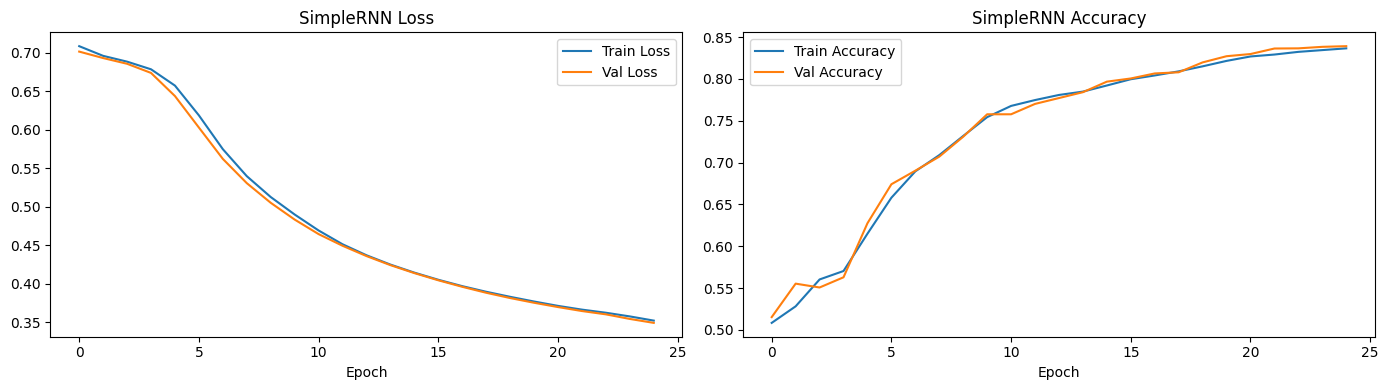

In [4]:
# Plot SimpleRNN training history
def plot_history(history, title_prefix='Model'):
    metrics = pd.DataFrame(history.history)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].plot(metrics['loss'], label='Train Loss')
    ax[0].plot(metrics['val_loss'], label='Val Loss')
    ax[0].set_title(f'{title_prefix} Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()

    ax[1].plot(metrics['accuracy'], label='Train Accuracy')
    ax[1].plot(metrics['val_accuracy'], label='Val Accuracy')
    ax[1].set_title(f'{title_prefix} Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(rnn_history, title_prefix='SimpleRNN')

## 5b: LSTM for Univariate Time-Series Prediction

In [5]:
# Prepare univariate time-series data
def split_sequence(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

raw_seq = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130], dtype='float32')
n_steps = 3

X_ts, y_ts = split_sequence(raw_seq, n_steps)
X_ts = X_ts.reshape((X_ts.shape[0], X_ts.shape[1], 1))

print('X_ts shape:', X_ts.shape)
print('y_ts shape:', y_ts.shape)
print('First sample:', X_ts[0].flatten(), '->', y_ts[0])

X_ts shape: (10, 3, 1)
y_ts shape: (10,)
First sample: [10. 20. 30.] -> 40.0


In [6]:
# Build and train LSTM model
lstm_model = keras.Sequential([
    layers.Input(shape=(n_steps, 1)),
    layers.LSTM(50, activation='relu'),
    layers.Dense(1),
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_ts,
    y_ts,
    epochs=300,
    verbose=0,
 )

print('Final training loss:', lstm_history.history['loss'][-1])
print('Final training MAE :', lstm_history.history['mae'][-1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Final training loss: 0.08070894330739975
Final training MAE : 0.16908416152000427


Input: [110. 120. 130.]
Predicted next value: 140.42051696777344


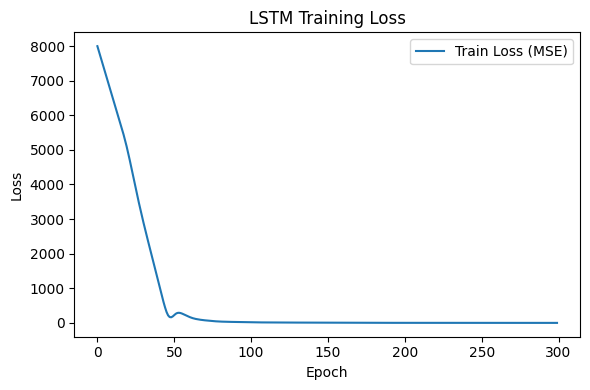

In [7]:
# Predict next value for [110, 120, 130]
x_input = np.array([110, 120, 130], dtype='float32').reshape((1, n_steps, 1))
yhat = lstm_model.predict(x_input, verbose=0)
print('Input:', x_input.flatten())
print('Predicted next value:', float(yhat[0][0]))

# Plot training loss for LSTM
plt.figure(figsize=(6, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss (MSE)')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()